# color classification

In [1]:
# import the libraries
import os
import random
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC

import imgaug as ia
import imgaug.augmenters as iaa
ia.seed(1)

In [2]:
def preprocess(img):
    '''
    process input image
    Args:
        img: input image
    Return:
        out: output image
    '''
    DIM = 200
    output = cv2.resize(img,(DIM,DIM),interpolation=cv2.INTER_AREA)
    return output

Text(0.5, 1.0, 'colors/charcoal/2.jpg')

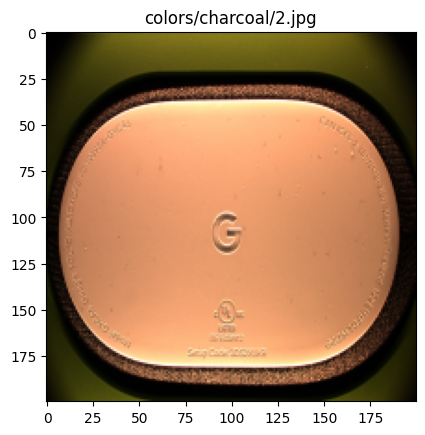

In [3]:
# random view one sample
path = "colors"
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
img = random.choice(imgs)
img_name = os.path.join(path,label,img)
img = cv2.imread(img_name)
img = preprocess(img)
plt.imshow(img)
plt.title(img_name)

In [4]:
for label in labels:
    # list images in color
    imgs = os.listdir(os.path.join(path,label))
    print(f'{label}:{len(imgs)}')

sage:10
sand:11
charcoal:10
sky:12
chalk:9


In [5]:
# image augmentation
augmentation = iaa.Sequential([
    # 1. Flip
    iaa.Fliplr(0.5),
    iaa.Flipud(0.5),
    
    # 2. Linearcontrast
    iaa.LinearContrast((0.8, 1.2)),
    
    # 3. Perform methods below only sometimes
    iaa.Sometimes(0.5,
                  
    # 4. GaussianBlur
    iaa.GaussianBlur((0.0, 3.0))
    )
    ])

training dataset

In [6]:
path2 = "train"

# create augmentation folder
if not os.path.exists(path2):
    os.mkdir(path2)

# create the labels in augmentation folder
for label in labels:
    if not os.path.exists(os.path.join(path2,label)):
        os.mkdir(os.path.join(path2,label))

N = 1000 # number of images augmented

for label in labels:
    # list all images
    imgs = os.listdir(os.path.join(path,label))
    m = len(imgs)
    # calculate the image augmentation number
    k = N//m
    
    print(label,"generating: ",k*m," images")
    
    for j,i in enumerate(imgs):
        im = cv2.imread(os.path.join(path,label,i))
        im = preprocess(im)
        ims = np.array([im for _ in range(k)],dtype=np.uint8)
        imaugs = augmentation(images=ims)
        
        for l,au in enumerate(imaugs):
            name= label+str(j)+str(l)+".jpg"
            cv2.imwrite(os.path.join(path2,label,name),au)

sage generating:  1000  images
sand generating:  990  images
charcoal generating:  1000  images
sky generating:  996  images
chalk generating:  999  images


testing dataset

In [7]:
path3 = "test"

# create augmentation folder
if not os.path.exists(path3):
    os.mkdir(path3)

# create the labels in augmentation folder
for label in labels:
    if not os.path.exists(os.path.join(path3,label)):
        os.mkdir(os.path.join(path3,label))

N = 1000 # number of images augmented

for label in labels:
    # list all images
    imgs = os.listdir(os.path.join(path,label))
    m = len(imgs)
    # calculate the image augmentation number
    k = N//m
    
    print(label,"generating: ",k*m," images")
    
    for j,i in enumerate(imgs):
        im = cv2.imread(os.path.join(path,label,i))
        im = preprocess(im)
        ims = np.array([im for _ in range(k)],dtype=np.uint8)
        imaugs = augmentation(images=ims)
        
        for l,au in enumerate(imaugs):
            name= label+str(j)+str(l)+".jpg"
            cv2.imwrite(os.path.join(path3,label,name),au)

sage generating:  1000  images
sand generating:  990  images
charcoal generating:  1000  images
sky generating:  996  images
chalk generating:  999  images


In [8]:
# generate dictionary of labels
labels = os.listdir(os.path.join(path2))
print(labels)
dic = {}
for k,l in enumerate(labels):
    dic[k]=l
dic

['sage', 'sand', 'charcoal', 'sky', 'chalk']


{0: 'sage', 1: 'sand', 2: 'charcoal', 3: 'sky', 4: 'chalk'}

In [9]:
dic_invert = {v:k for k,v in dic.items()}
dic_invert

{'sage': 0, 'sand': 1, 'charcoal': 2, 'sky': 3, 'chalk': 4}

In [10]:
X = []
y = []
for label in labels:
    for i in os.listdir(os.path.join(path2,label)):
        img = cv2.imread(os.path.join(path2,label,i))
        X.append(img)
        y.append(dic_invert[label])

In [11]:
X = np.array(X).reshape(len(X),-1)
# norm
X = X/255.0
y = np.array(y)

In [12]:
# shuffle
X,y = shuffle(X,y)

In [13]:
print(X.shape)
print(y.shape)

(4975, 120000)
(4975,)


In [14]:
# split train val subset
X_train, X_val, y_train, y_val = train_test_split(X,y)

In [15]:
# train model
svc = SVC(kernel='linear',gamma='auto') #linear,rbf
svc.fit(X_train, y_train)

SVC(gamma='auto', kernel='linear')

In [16]:
# Predict the output of model after above parameters are applied to it
preds = svc.predict(X_val)

In [17]:
# report
print("Prediction report",classification_report(y_val,preds))

Prediction report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       245
           1       1.00      1.00      1.00       261
           2       1.00      1.00      1.00       245
           3       1.00      1.00      1.00       230
           4       1.00      1.00      1.00       263

    accuracy                           1.00      1244
   macro avg       1.00      1.00      1.00      1244
weighted avg       1.00      1.00      1.00      1244



In [18]:
del X_train
del y_train
del X_val
del y_val

In [19]:
# save the model to disk
filename = 'classifier.sav'
pickle.dump(svc, open(filename, 'wb'))

In [20]:
# load saved model
filename = 'classifier.sav'
loaded_model = pickle.load(open(filename,'rb'))

In [21]:
# test on test set
path = 'test'
labels = os.listdir(path)
for label in labels:
    # list all image
    imgs = os.listdir(os.path.join(path,label))
    # load image and predict
    X = []
    y = []
    for i in imgs:
        img = cv2.imread(os.path.join(path,label,i))
        img = preprocess(img)
        img = img/255
        X.append(img)
        k = dic_invert[label]
        y.append(k)
    # preprocess images
    X = np.array(X).reshape(len(X),-1)
    y = np.array(y)
    # predict
    preds = loaded_model.predict(X)
    # calc accuracy
    print("Accuracy on ",label," ",len(imgs)," images is",accuracy_score(y,preds))

Accuracy on  sage   1000  images is 1.0
Accuracy on  sand   990  images is 1.0
Accuracy on  charcoal   1000  images is 1.0
Accuracy on  sky   986  images is 1.0
Accuracy on  chalk   999  images is 1.0


In [22]:
# test on original set
path = 'colors'
labels = os.listdir(path)
for label in labels:
    # list all image
    imgs = os.listdir(os.path.join(path,label))
    # load image and predict
    X = []
    y = []
    for i in imgs:
        img = cv2.imread(os.path.join(path,label,i))
        img = preprocess(img)
        img = img/255
        X.append(img)
        k = dic_invert[label]
        y.append(k)
    # preprocess images
    X = np.array(X).reshape(len(X),-1)
    y = np.array(y)
    # predict
    preds = loaded_model.predict(X)
    # calc accuracy
    print("Accuracy on ",label," ",len(imgs)," images is",accuracy_score(y,preds))

Accuracy on  sage   10  images is 1.0
Accuracy on  sand   11  images is 1.0
Accuracy on  charcoal   10  images is 1.0
Accuracy on  sky   12  images is 1.0
Accuracy on  chalk   9  images is 1.0


Text(0.5, 1.0, 'sky(sky)')

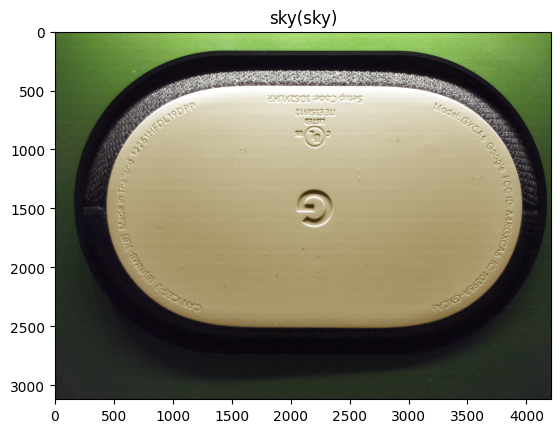

In [23]:
# random test
path = 'colors'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
img = random.choice(imgs)
img = cv2.imread(os.path.join(path,label,img))
img_org = img.copy()
#predict
img = preprocess(img)
img = img/255.0
img = img.reshape(1,-1)
pred = loaded_model.predict(img)
# displat
plt.imshow(img_org)
title = dic[pred[0]]+"("+label+")"
plt.title(title)

In [24]:
!rm -rf train
!rm -rf test

# validate input images

In [26]:
import os
import random
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

import imgaug as ia
import imgaug.augmenters as iaa
ia.seed(1)

In [27]:
def preprocess(img):
    '''
    process input image
    Args:
        img: input image
    Return:
        out: output image
    '''
    DIM = 100
    output = cv2.resize(img,(DIM,DIM),interpolation=cv2.INTER_AREA)
    return output

Text(0.5, 1.0, 'inputs/unval/image_10022023111931.jpg')

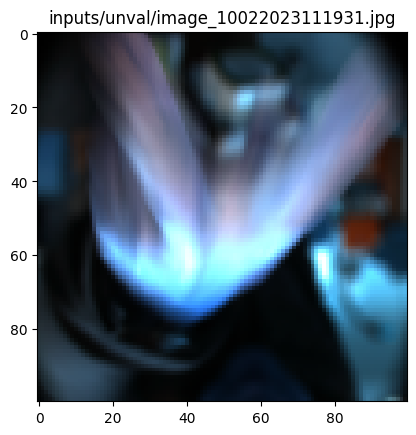

In [28]:
# random view one sample
path = "inputs"
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
img = random.choice(imgs)
img_name = os.path.join(path,label,img)
img = cv2.imread(img_name)
img = preprocess(img)
plt.imshow(img)
plt.title(img_name)

In [29]:
for label in labels:
    # list images in label
    imgs = os.listdir(os.path.join(path,label))
    print(f'{label}:{len(imgs)}')

val:5
unval:5


In [30]:
# image augmentation
augmentation = iaa.Sequential([
    # 1. Flip
    iaa.Fliplr(0.5),
    iaa.Flipud(0.5),
    
    # 2. Linearcontrast
    iaa.LinearContrast((0.8, 1.2)),
    
    # 3. Perform methods below only sometimes
    iaa.Sometimes(0.5,
                  
    # 4. GaussianBlur
    iaa.GaussianBlur((0.0, 3.0))
    )
    ])

In [31]:
path2 = "train"

# create augmentation folder
if not os.path.exists(path2):
    os.mkdir(path2)

# create the labels in augmentation folder
for label in labels:
    if not os.path.exists(os.path.join(path2,label)):
        os.mkdir(os.path.join(path2,label))

N = 1000 # number of images augmented

for label in labels:
    # list all images
    imgs = os.listdir(os.path.join(path,label))
    m = len(imgs)
    # calculate the image augmentation number
    k = N//m
    
    print(label,"generating: ",k*m," images")
    
    for j,i in enumerate(imgs):
        im = cv2.imread(os.path.join(path,label,i))
        im = preprocess(im)
        ims = np.array([im for _ in range(k)],dtype=np.uint8)
        imaugs = augmentation(images=ims)
        
        for l,au in enumerate(imaugs):
            name= label+str(j)+str(l)+".jpg"
            cv2.imwrite(os.path.join(path2,label,name),au)

val generating:  1000  images
unval generating:  1000  images


In [32]:
path3 = "test"

# create augmentation folder
if not os.path.exists(path3):
    os.mkdir(path3)

# create the labels in augmentation folder
for label in labels:
    if not os.path.exists(os.path.join(path3,label)):
        os.mkdir(os.path.join(path3,label))

N = 1000 # number of images augmented

for label in labels:
    # list all images
    imgs = os.listdir(os.path.join(path,label))
    m = len(imgs)
    # calculate the image augmentation number
    k = N//m
    
    print(label,"generating: ",k*m," images")
    
    for j,i in enumerate(imgs):
        im = cv2.imread(os.path.join(path,label,i))
        im = preprocess(im)
        ims = np.array([im for _ in range(k)],dtype=np.uint8)
        imaugs = augmentation(images=ims)
        
        for l,au in enumerate(imaugs):
            name= label+str(j)+str(l)+".jpg"
            cv2.imwrite(os.path.join(path3,label,name),au)

val generating:  1000  images
unval generating:  1000  images


In [33]:
# generate dictionary of labels
labels = os.listdir(os.path.join(path2))
print(labels)
dic = {}
for k,l in enumerate(labels):
    dic[k]=l
dic

['val', 'unval']


{0: 'val', 1: 'unval'}

In [34]:
dic_invert = {v:k for k,v in dic.items()}
dic_invert

{'val': 0, 'unval': 1}

In [35]:
X = []
y = []
for label in labels:
    for i in os.listdir(os.path.join(path2,label)):
        img = cv2.imread(os.path.join(path2,label,i))
        X.append(img)
        y.append(dic_invert[label])

In [36]:
X = np.array(X).reshape(len(X),-1)
# norm
X = X/255.0
y = np.array(y)

In [37]:
# shuffle
X,y = shuffle(X,y)

In [38]:
print(X.shape)
print(y.shape)

(2000, 30000)
(2000,)


In [39]:
# split train val subset
X_train, X_val, y_train, y_val = train_test_split(X,y)

In [40]:
# train model
svc = SVC(kernel='linear',gamma='auto') #linear,rbf
svc.fit(X_train, y_train)

SVC(gamma='auto', kernel='linear')

In [41]:
# Predict the output of model after above parameters are applied to it
preds = svc.predict(X_val)

In [42]:
# report
print("Prediction report",classification_report(y_val,preds))

Prediction report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       251
           1       1.00      1.00      1.00       249

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [43]:
del X_train
del y_train
del X_val
del y_val

In [44]:
# save the model to disk
filename = 'validator.sav'
pickle.dump(svc, open(filename, 'wb'))

In [45]:
# load saved model
filename = 'validator.sav'
loaded_model = pickle.load(open(filename,'rb'))

In [46]:
# test on test set
path = 'test'
labels = os.listdir(path)
for label in labels:
    # list all image
    imgs = os.listdir(os.path.join(path,label))
    # load image and predict
    X = []
    y = []
    for i in imgs:
        img = cv2.imread(os.path.join(path,label,i))
        img = preprocess(img)
        img = img/255
        X.append(img)
        k = dic_invert[label]
        y.append(k)
    # preprocess images
    X = np.array(X).reshape(len(X),-1)
    y = np.array(y)
    # predict
    preds = loaded_model.predict(X)
    # calc accuracy
    print("Accuracy on ",label," ",len(imgs)," images is",accuracy_score(y,preds))

Accuracy on  val   1000  images is 1.0
Accuracy on  unval   1000  images is 1.0


In [47]:
# test on original set
path = 'inputs'
labels = os.listdir(path)
for label in labels:
    # list all image
    imgs = os.listdir(os.path.join(path,label))
    # load image and predict
    X = []
    y = []
    for i in imgs:
        img = cv2.imread(os.path.join(path,label,i))
        img = preprocess(img)
        img = img/255
        X.append(img)
        k = dic_invert[label]
        y.append(k)
    # preprocess images
    X = np.array(X).reshape(len(X),-1)
    y = np.array(y)
    # predict
    preds = loaded_model.predict(X)
    # calc accuracy
    print("Accuracy on ",label," ",len(imgs)," images is",accuracy_score(y,preds))

Accuracy on  val   5  images is 1.0
Accuracy on  unval   5  images is 1.0


Text(0.5, 1.0, 'val(val)')

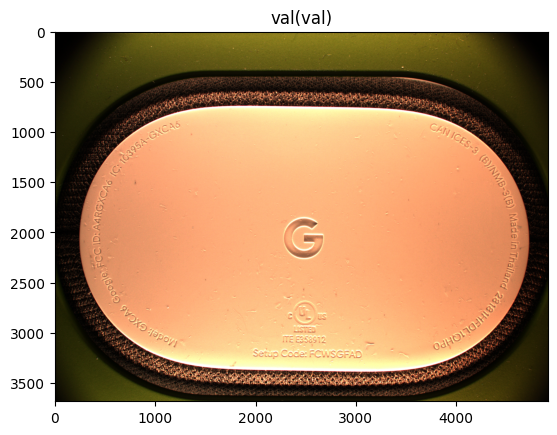

In [48]:
# random test
path = 'inputs'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
img = random.choice(imgs)
img = cv2.imread(os.path.join(path,label,img))
img_org = img.copy()
#predict
img = preprocess(img)
img = img/255.0
img = img.reshape(1,-1)
pred = loaded_model.predict(img)
# displat
plt.imshow(img_org)
title = dic[pred[0]]+"("+label+")"
plt.title(title)

In [49]:
!rm -rf train
!rm -rf test

# deploy

In [66]:
# import the libraries
import os
import cv2
import csv
import pickle
import matplotlib.pyplot as plt

In [60]:
def preprocess(img):
    '''
    process input image for classifier
    Args:
        img: input image
    Return:
        out: output image
    '''
    DIM = 200
    img = img/255.0
    output = cv2.resize(img,(DIM,DIM),interpolation=cv2.INTER_AREA)
    return output

def preprocess2(img):
    '''
    process input image for validator
    Args:
        img: input image
    Return:
        out: output image
    '''
    DIM = 100
    img = img/255.0
    output = cv2.resize(img,(DIM,DIM),interpolation=cv2.INTER_AREA)
    return output

In [58]:
# load saved model
filename = 'classifier.sav'
classifier = pickle.load(open(filename,'rb'))

filename = 'validator.sav'
validator = pickle.load(open(filename,'rb'))

In [62]:
# load dictionaries
dic = {0: 'sage', 1: 'sand', 2: 'charcoal', 3: 'sky', 4: 'chalk'}
dic2 = {0: 'val', 1: 'unval'}

In [70]:
path = 'sessions'
imgs = os.listdir(path)

fields = ['No','Image','Color','Valid','Note']
file = open('predict.csv','w',encoding='UTF8')
writer = csv.writer(file)
writer.writerow(fields)
    
for i in range(len(imgs)):
    img = cv2.imread(os.path.join(path,imgs[i]))
    out1 = preprocess(img)
    out1 = out1.reshape(1,-1)
    out2 = preprocess2(img)
    out2 = out2.reshape(1,-1)
    y1 = classifier.predict(out1)
    y2 = validator.predict(out2)
    print(i+1,imgs[i],dic[y1[0]],dic2[y2[0]])
    writer.writerow([i+1,imgs[i],dic[y1[0]],dic2[y2[0]]])

# close csv file
file.close()

1 image_10022023111724.jpg chalk val
2 image_10022023111406.jpg chalk val
3 image_10022023111931.jpg sand unval
4 image_08022023020208.jpg sand unval
5 image_08022023011100.jpg charcoal val
6 image_08022023011639.jpg chalk val
7 image_08022023015647.jpg charcoal val
8 image_10022023111711.jpg chalk val
9 image_10022023111833.jpg chalk val
10 image_08022023010634.jpg chalk val
11 image_10022023111738.jpg chalk val
12 image_08022023015617.jpg charcoal val
13 image_08022023015750.jpg charcoal val
14 image_10022023111442.jpg chalk val
15 image_08022023011416.jpg chalk val
16 image_08022023013527.jpg sand unval
17 image_10022023112006.jpg chalk val
18 image_10022023111549.jpg charcoal unval
19 image_10022023111953.jpg chalk val
20 image_08022023010858.jpg chalk val
21 image_08022023012931.jpg chalk val
22 image_10022023111749.jpg chalk val
23 image_10022023111431.jpg chalk val
24 image_10022023111808.jpg chalk val
25 image_10022023112016.jpg chalk val
26 image_08022023013009.jpg chalk val
2

# references

[sklearn_object_classification](https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/27_cell_classification/sklearn_object_classification.html)

[Image_Classification_using_SVM](https://github.com/aditi-govindu/Image-Classsification-using-sklearn/blob/main/Image_Classification_using_SVM.ipynb)

[image-classification-with-scikit-learn](https://kapernikov.com/tutorial-image-classification-with-scikit-learn/)